In [31]:
import pandas as pd
import openpyxl

In [32]:
df = pd.read_excel('HR Data.xlsx')
df.head()

,Employee Number,emp no,Exited,Business Travel,Age Group,Employee status,Department,Education Field,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,1,STAFF-1,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
1,2,STAFF-2,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
2,4,STAFF-4,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
3,5,STAFF-5,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,7,STAFF-7,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2


In [33]:
df_copied = df.copy()
df_copied.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Employee Number             1470 non-null   int64
 1   emp no                      1470 non-null   str  
 2   Exited                      1470 non-null   str  
 3   Business Travel             1470 non-null   str  
 4   Age Group                   1470 non-null   str  
 5   Employee status             1470 non-null   str  
 6   Department                  1470 non-null   str  
 7   Education Field             1470 non-null   str  
 8   Gender                      1470 non-null   str  
 9   Job Role                    1470 non-null   str  
 10  Marital Status              1470 non-null   str  
 11  Over Time                   1470 non-null   str  
 12  Over18                      1470 non-null   str  
 13  Training Times Last Year    1470 non-null   int64
 14  -2                 

In [34]:
df_copied.isna().sum()

Employee Number               0
emp no                        0
Exited                        0
Business Travel               0
Age Group                     0
Employee status               0
Department                    0
Education Field               0
Gender                        0
Job Role                      0
Marital Status                0
Over Time                     0
Over18                        0
Training Times Last Year      0
-2                            0
0                             0
Age                           0
CF_current Employee           0
Daily Rate                    0
Distance From Home            0
Education                     0
Employee Count                0
Environment Satisfaction      0
Hourly Rate                   0
Job Involvement               0
Job Level                     0
Job Satisfaction              0
Monthly Income                0
Monthly Rate                  0
Num Companies Worked          0
Percent Salary Hike           0
Performa

In [35]:
df_cleaned = df_copied.drop(columns=['emp no','Employee status','Over18',-2,0,'CF_current Employee','Employee Count','Standard Hours'])


In [87]:
df_cleaned.to_excel('Cleaned HR Data.xlsx')

In [ ]:
df_cleaned.info()

In [36]:
mydf = df_cleaned.copy()

In [41]:
total_exited_num =mydf.groupby('Exited').agg(
    Total_Employees=('Exited', 'count'),
    
)
total_exited_num
total_exited_num["Percentage"] = (total_exited_num["Total_Employees"] / total_exited_num["Total_Employees"].sum()) * 100
total_exited_num

,Total_Employees,Percentage
Exited,,
No,1233,83.877551
Yes,237,16.122449


In [43]:

business_travel = mydf.pivot_table(
    values='Employee Number',
    index='Business Travel',
    columns='Exited',
    aggfunc='count'
)
business_travel['Total Count'] = business_travel.sum(axis=1)
business_travel['Percentage'] = business_travel['Yes'] * 100/ business_travel['Total Count']
business_travel.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Business Travel,,,,
Travel_Frequently,208,69,277,24.909747
Travel_Rarely,887,156,1043,14.956855
Non-Travel,138,12,150,8.000000


In [44]:
job_role = mydf.pivot_table(
    values='Employee Number',
    index='Job Role',
    columns='Exited',
    aggfunc='count'
)
job_role['Total'] = job_role['Yes'] + job_role['No']

job_role['Percentage'] = job_role['Yes'] / (job_role['Total']) * 100
job_role.sort_values(by='Percentage', ascending=False, inplace=True)
job_role

Exited,No,Yes,Total,Percentage
Job Role,,,,
Sales Representative,50,33,83,39.759036
Laboratory Technician,197,62,259,23.938224
Human Resources,40,12,52,23.076923
Sales Executive,269,57,326,17.484663
Research Scientist,245,47,292,16.095890
Manufacturing Director,135,10,145,6.896552
Healthcare Representative,122,9,131,6.870229
Manager,97,5,102,4.901961
Research Director,78,2,80,2.500000


In [45]:
department = mydf.pivot_table(
    values='Employee Number',
    index='Department',
    columns='Exited',
    aggfunc='count'
)
department['Total Count'] = department.sum(axis=1)
department['Percentage'] = department['Yes'] * 100/ department['Total Count']
department.sort_values(by='Percentage', ascending=False)


Exited,No,Yes,Total Count,Percentage
Department,,,,
Sales,354,92,446,20.627803
HR,51,12,63,19.047619
R&D,828,133,961,13.839750


In [85]:
age_group = mydf.pivot_table(
    values='Employee Number',
    index='Age Group',
    columns='Exited',
    aggfunc='count'
)
age_group['Total Count'] = age_group.sum(axis=1)
age_group['Percentage'] = age_group['Yes'] * 100/ age_group['Total Count']
age_group.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Age Group,,,,
Under 25,59,38,97,39.175258
25 - 34,442,112,554,20.216606
Over 55,58,11,69,15.942029
45 - 54,220,25,245,10.204082
35 - 44,454,51,505,10.099010


In [47]:
over_time = mydf.pivot_table(
    values='Employee Number',
    index='Over Time',
    columns='Exited',
    aggfunc='count'
)
over_time['Total Count'] = over_time.sum(axis=1)
over_time['Percentage'] = over_time['Yes'] * 100/ over_time['Total Count']
over_time.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Over Time,,,,
Yes,289,127,416,30.528846
No,944,110,1054,10.436433


In [ ]:
distance_from_home =mydf.pivot_table(
    values='Employee Number',
    index='Distance From Home',
    columns='Exited',
    aggfunc='count'
)
distance_from_home['Total Count'] = distance_from_home.sum(axis=1)
distance_from_home['Percentage'] = distance_from_home['Yes'] * 100/ distance_from_home['Total Count']
distance_from_home.sort_values(by='Percentage', ascending=False).head(10)

In [60]:
environment_satisfaction = mydf.pivot_table(
    values='Employee Number',
    index='Environment Satisfaction',
    columns='Exited',
    aggfunc='count'
)
environment_satisfaction['Total Count'] = environment_satisfaction.sum(axis=1)
environment_satisfaction['Percentage'] = environment_satisfaction['Yes'] * 100/ environment_satisfaction['Total Count']
environment_satisfaction.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Environment Satisfaction,,,,
1,212,72,284,25.352113
2,244,43,287,14.982578
3,391,62,453,13.686534
4,386,60,446,13.452915


In [65]:
job_involvement = mydf.pivot_table(
    values='Employee Number',
    index='Job Involvement',
    columns='Exited',
    aggfunc='count'
)
job_involvement['Total Count'] = job_involvement.sum(axis=1)
job_involvement['Percentage'] = job_involvement['Yes'] * 100/ job_involvement['Total Count']
job_involvement.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Job Involvement,,,,
1,55,28,83,33.734940
2,304,71,375,18.933333
3,743,125,868,14.400922
4,131,13,144,9.027778


In [50]:
job_level = mydf.pivot_table(
    values='Employee Number',
    index='Job Level',
    columns='Exited',
    aggfunc='count'
)
job_level['Total Count'] = job_level.sum(axis=1)
job_level['Percentage'] = job_level['Yes'] * 100/ job_level['Total Count']
job_level.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Job Level,,,,
1,400,143,543,26.335175
3,186,32,218,14.678899
2,482,52,534,9.737828
5,64,5,69,7.246377
4,101,5,106,4.716981


In [51]:
job_satisfaction = mydf.pivot_table(
    values='Employee Number',
    index='Job Satisfaction',
    columns='Exited',
    aggfunc='count'
)
job_satisfaction['Total Count'] = job_satisfaction.sum(axis=1)
job_satisfaction['Percentage'] = job_satisfaction['Yes'] * 100/ job_satisfaction['Total Count']
job_satisfaction.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Job Satisfaction,,,,
1,223,66,289,22.837370
3,369,73,442,16.515837
2,234,46,280,16.428571
4,407,52,459,11.328976


In [52]:
work_life_balance = mydf.pivot_table(
    values='Employee Number',
    index='Work Life Balance',
    columns='Exited',
    aggfunc='count'
)
work_life_balance['Total Count'] = work_life_balance.sum(axis=1)
work_life_balance['Percentage'] = work_life_balance['Yes'] * 100/ work_life_balance['Total Count']
work_life_balance.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Work Life Balance,,,,
1,55,25,80,31.250000
4,126,27,153,17.647059
2,286,58,344,16.860465
3,766,127,893,14.221725


In [53]:
years_at_company = mydf.pivot_table(
    values='Employee Number',
    index='Years At Company',
    columns='Exited',
    aggfunc='count'
).fillna(0)
years_at_company['Total Count'] = years_at_company.sum(axis=1)
years_at_company['Percentage'] = years_at_company['Yes'] * 100/ years_at_company['Total Count']
years_at_company.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Years At Company,,,,
40,0.0,1.0,1.0,100.000000
23,1.0,1.0,2.0,50.000000
0,28.0,16.0,44.0,36.363636
1,112.0,59.0,171.0,34.502924
32,2.0,1.0,3.0,33.333333
31,2.0,1.0,3.0,33.333333
2,100.0,27.0,127.0,21.259843
33,4.0,1.0,5.0,20.000000
4,91.0,19.0,110.0,17.272727


In [54]:
years_in_current_role = mydf.pivot_table(
    values='Employee Number',
    index='Years In Current Role',
    columns='Exited',
    aggfunc='count'
).fillna(0)
years_in_current_role['Total Count'] = years_in_current_role.sum(axis=1)
years_in_current_role['Percentage'] = years_in_current_role['Yes'] * 100/ years_in_current_role['Total Count']
years_in_current_role.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Years In Current Role,,,,
0,171.0,73.0,244.0,29.918033
15,6.0,2.0,8.0,25.000000
1,46.0,11.0,57.0,19.298246
2,304.0,68.0,372.0,18.279570
4,89.0,15.0,104.0,14.423077
7,191.0,31.0,222.0,13.963964
3,119.0,16.0,135.0,11.851852
12,9.0,1.0,10.0,10.000000
14,10.0,1.0,11.0,9.090909


In [55]:
years_since_last_promotion = mydf.pivot_table(
    values='Employee Number',
    index='Years Since Last Promotion',
    columns='Exited',
    aggfunc='count'
).fillna(0)
years_since_last_promotion['Total Count'] = years_since_last_promotion.sum(axis=1)
years_since_last_promotion['Percentage'] = years_since_last_promotion['Yes'] * 100/ years_since_last_promotion['Total Count']
years_since_last_promotion.sort_values(by='Percentage', ascending=False)

Exited,No,Yes,Total Count,Percentage
Years Since Last Promotion,,,,
9,13.0,4.0,17.0,23.529412
15,10.0,3.0,13.0,23.076923
7,60.0,16.0,76.0,21.052632
13,8.0,2.0,10.0,20.000000
0,471.0,110.0,581.0,18.932874
6,26.0,6.0,32.0,18.750000
3,43.0,9.0,52.0,17.307692
2,132.0,27.0,159.0,16.981132
10,5.0,1.0,6.0,16.666667


In [ ]:
years_wth_curr_manager = mydf.pivot_table(
    values='Employee Number',
    index='Years With Curr Manager',
    columns='Exited',
    aggfunc='count'
).fillna(0)
years_wth_curr_manager['Total Count'] = years_wth_curr_manager.sum(axis=1)
years_wth_curr_manager['Percentage'] = years_wth_curr_manager['Yes'] * 100/ years_wth_curr_manager['Total Count']
years_wth_curr_manager.sort_values(by='Percentage', ascending=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plotting(result, column_name):
    plt.figure(figsize=(8, 5))          # size of the chart
    sns.barplot(data=result, x=result.index, y='Percentage')  # the actual plot
    plt.title(f'Attrition Rate by {column_name}')
    plt.ylabel('Attrition %')
    plt.xticks(rotation=45)             # rotate labels if they overlap
    plt.show()

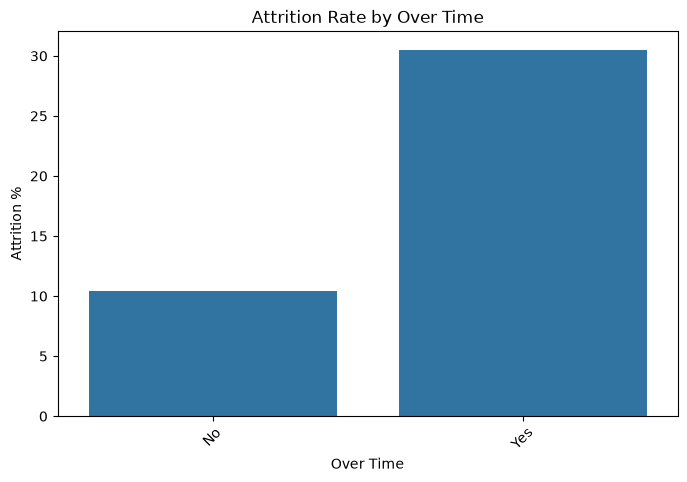

In [69]:
plotting(over_time,"Over Time")

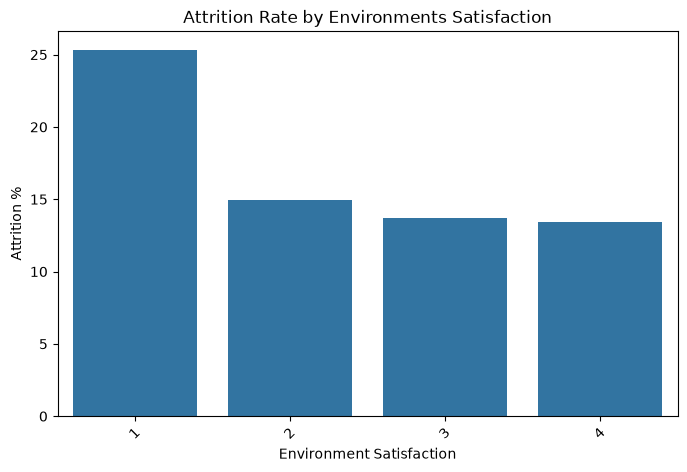

In [70]:
plotting(environment_satisfaction,'Environments Satisfaction')

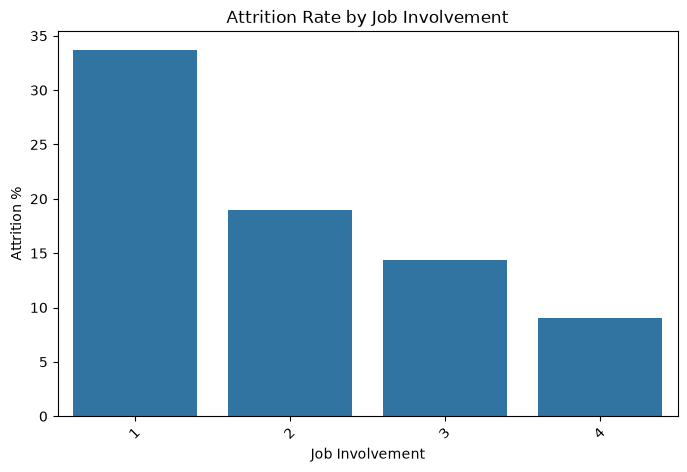

In [71]:
plotting(job_involvement,'Job Involvement')

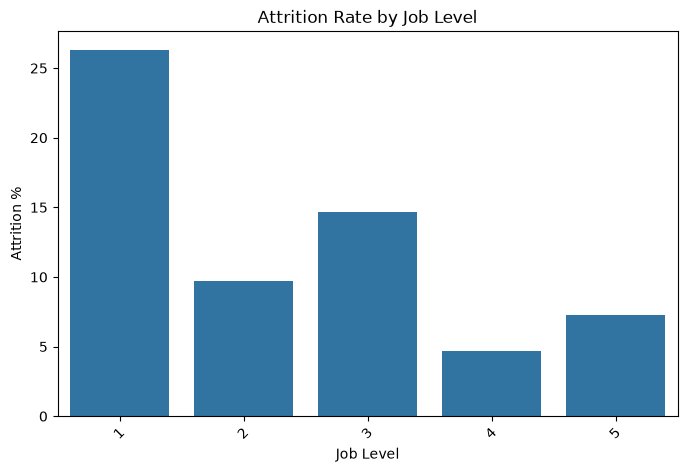

In [72]:
plotting(job_level,"Job Level")

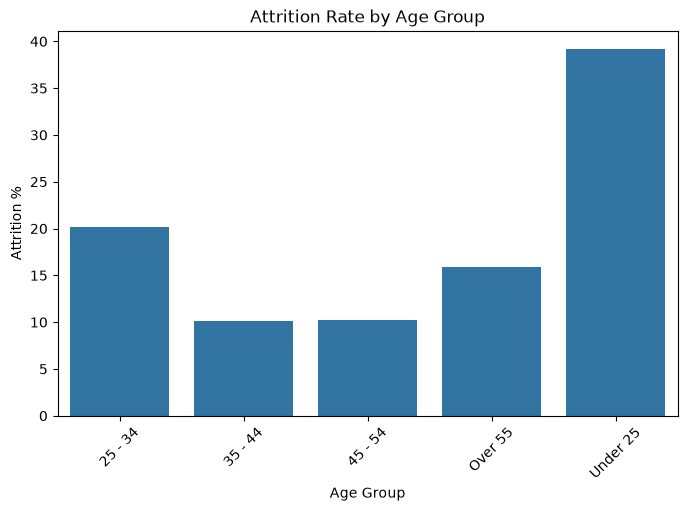

In [86]:
plotting(age_group,"Age Group")